In [ ]:
import pandas as pd
import os

# Set the path to the folder
folder_path = 'raw_data'

# Get a list of all CSV files in that folder
file_list = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Create an empty list to hold each month's data
df_list = []

# Loop through the files, read them, and append them to the list
for file in file_list:
    full_path = os.path.join(folder_path, file)
    df = pd.read_csv(full_path)
    df_list.append(df)

# Concatenate all 12 dataframes into one giant dataframe
cyclistic_df = pd.concat(df_list, ignore_index=True)

#  This prints the total rows and the first 5 rows of data
print(f"Total rows: {len(cyclistic_df)}")
cyclistic_df.head()

Total rows: 5620544


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member


In [ ]:
# The info() command
#  the column names, how many rows there are, and the data type (string, integer, float) of each column.
print("--- DATA OVERVIEW ---")
cyclistic_df.info()

# The duplicated() command checks every row against every other row to see if they are identical.
# The .sum() at the end just adds them all up so we get a single number.
duplicates = cyclistic_df.duplicated().sum()
print(f"\nTotal exact duplicate rows: {duplicates}")

# The isnull() command checks for missing data (blank cells).
# use .sum() to count how many blanks exist in each specific column.
print("\n--- MISSING VALUES PER COLUMN ---")
print(cyclistic_df.isnull().sum())

--- DATA OVERVIEW ---
<class 'pandas.DataFrame'>
RangeIndex: 5620544 entries, 0 to 5620543
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), str(9)
memory usage: 557.5 MB

Total exact duplicate rows: 0

--- MISSING VALUES PER COLUMN ---
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1194952
start_station_id      1194952
end_station_name      1259214
end_station_id        1259214
start_lat                

In [ ]:
# Compare average ride length: Members vs. Casual Riders
# group by user type and calculate the average of the ride_length column
avg_ride_length = cyclistic_clean.groupby('member_casual')['ride_length'].mean()
print("--- AVERAGE RIDE LENGTH ---")
print(avg_ride_length)

# Compare the total number of rides by day of the week for each user type
# We group by BOTH user type and day of the week, then count the number of ride_ids
rides_by_day = cyclistic_clean.groupby(['member_casual', 'day_of_week'])['ride_id'].count()
print("\n--- TOTAL RIDES BY DAY OF WEEK ---")
print(rides_by_day)

# Find the maximum ride length overall 
max_ride = cyclistic_clean['ride_length'].max()
print(f"\n--- MAXIMUM RIDE LENGTH: {max_ride} ---")

--- AVERAGE RIDE LENGTH ---
member_casual
casual   0 days 00:22:17.024319
member   0 days 00:12:26.989199
Name: ride_length, dtype: timedelta64[us]

--- TOTAL RIDES BY DAY OF WEEK ---
member_casual  day_of_week
casual         Friday         206777
               Monday         159164
               Saturday       275574
               Sunday         227607
               Thursday       167376
               Tuesday        149919
               Wednesday      145114
member         Friday         349424
               Monday         354926
               Saturday       286374
               Sunday         254162
               Thursday       386298
               Tuesday        396710
               Wednesday      379801
Name: ride_id, dtype: int64

--- MAXIMUM RIDE LENGTH: 1 days 00:59:38.262000 ---


In [ ]:
#  Extract the hour (0-23) from the started_at timestamp
cyclistic_clean['start_hour'] = cyclistic_clean['started_at'].dt.hour

# Group by user type and hour, then count the rides
rides_by_hour = cyclistic_clean.groupby(['member_casual', 'start_hour'])['ride_id'].count()

print("--- TOTAL RIDES BY HOUR OF DAY ---")
print(rides_by_hour)

--- TOTAL RIDES BY HOUR OF DAY ---
member_casual  start_hour
casual         0              23304
               1              14468
               2               9415
               3               5037
               4               4057
               5               7425
               6              18059
               7              33940
               8              47828
               9              48245
               10             59935
               11             76161
               12             89290
               13             91506
               14             96521
               15            106241
               16            121956
               17            128428
               18            105474
               19             76377
               20             54525
               21             46389
               22             38688
               23             28262
member         0              17680
               1              10342
   

In [ ]:
# Extract the month name from the timestamp
cyclistic_clean['month'] = cyclistic_clean['started_at'].dt.month_name()

# Group by user type and month, then count
rides_by_month = cyclistic_clean.groupby(['member_casual', 'month'])['ride_id'].count()
print("--- TOTAL RIDES BY MONTH ---")
print(rides_by_month)

# Group by user type and bike type 
rides_by_bike = cyclistic_clean.groupby(['member_casual', 'rideable_type'])['ride_id'].count()
print("\n--- BIKE TYPE PREFERENCE ---")
print(rides_by_bike)

--- TOTAL RIDES BY MONTH ---
member_casual  month    
casual         April         77018
               August       221294
               December      18841
               February      29640
               January       16555
               July         208733
               June         193128
               March         60489
               May          125697
               November      64203
               October      143546
               September    172387
member         April        181859
               August       294344
               December      77326
               February     117985
               January       80558
               July         285552
               June         253192
               March        161410
               May          215010
               November     170729
               October      274356
               September    295374
Name: ride_id, dtype: int64

--- BIKE TYPE PREFERENCE ---
member_casual  rideable_type
casual         clas

In [ ]:
# Define the correct chronological order
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

# Typecasting: Convert the 'month' column to a Categorical data type
cyclistic_clean['month'] = pd.Categorical(cyclistic_clean['month'], categories=months_order, ordered=True)

# it will sort by the chronological order
rides_by_month_ordered = cyclistic_clean.groupby(['member_casual', 'month'])['ride_id'].count()

print("--- TOTAL RIDES BY MONTH (CHRONOLOGICAL) ---")
print(rides_by_month_ordered)

--- TOTAL RIDES BY MONTH (CHRONOLOGICAL) ---
member_casual  month    
casual         January       16555
               February      29640
               March         60489
               April         77018
               May          125697
               June         193128
               July         208733
               August       221294
               September    172387
               October      143546
               November      64203
               December      18841
member         January       80558
               February     117985
               March        161410
               April        181859
               May          215010
               June         253192
               July         285552
               August       294344
               September    295374
               October      274356
               November     170729
               December      77326
Name: ride_id, dtype: int64


In [9]:
# Save the cleaned dataframe to a new CSV file without the index column
cyclistic_clean.to_csv('cyclistic_clean_data.csv', index=False)
print("Data successfully saved!")

Data successfully saved!


In [10]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------------------

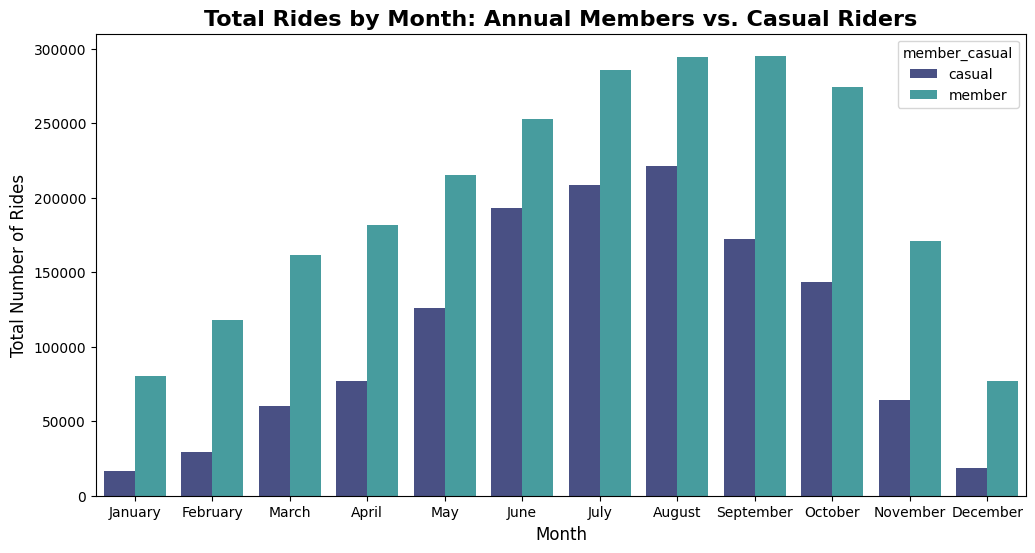

In [ ]:
#Import visual libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data
monthly_summary = cyclistic_clean.groupby(['month', 'member_casual'], as_index=False)['ride_id'].count()

# Set up the canvas size (12 inches wide, 6 inches tall)
plt.figure(figsize=(12, 6))

# the Bar Chart
# x = the months on the bottom
# y = the total rides on the side
# hue = splits the bars by user type (member vs casual)
sns.barplot(data=monthly_summary, x='month', y='ride_id', hue='member_casual', palette='mako')

# Add professional formatting (Titles and Labels)
plt.title('Total Rides by Month: Annual Members vs. Casual Riders', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Number of Rides', fontsize=12)

# Format the y-axis so it doesn't use scientific notation 
plt.ticklabel_format(style='plain', axis='y')

# Show the final chart
plt.show()

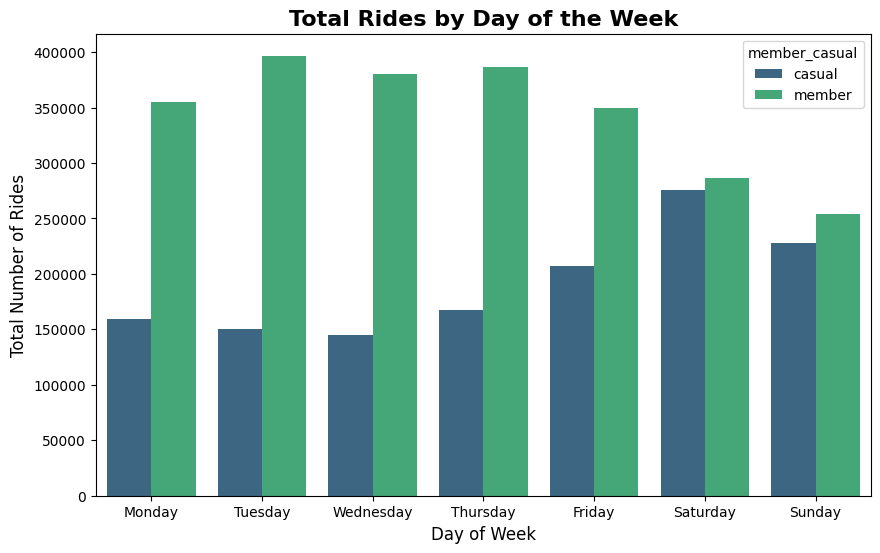

In [ ]:
#  Define the chronological order for the days of the week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


daily_summary = cyclistic_clean.groupby(['day_of_week', 'member_casual'], as_index=False)['ride_id'].count()


plt.figure(figsize=(10, 6))


sns.barplot(data=daily_summary, x='day_of_week', y='ride_id', hue='member_casual', palette='viridis', order=days_order)


plt.title('Total Rides by Day of the Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Total Number of Rides', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

#  Show the chart
plt.show()

In [ ]:
# Remove missing values
# drop rows with missing data and save it to a brand new variable: 'cyclistic_clean'
cyclistic_clean = cyclistic_df.dropna().copy()

# Typecasting: Convert the time columns from strings to datetime objects
cyclistic_clean['started_at'] = pd.to_datetime(cyclistic_clean['started_at'])
cyclistic_clean['ended_at'] = pd.to_datetime(cyclistic_clean['ended_at'])

# Create the 'ride_length' column (End time minus Start time)
cyclistic_clean['ride_length'] = cyclistic_clean['ended_at'] - cyclistic_clean['started_at']

# Create the 'day_of_week' column
cyclistic_clean['day_of_week'] = cyclistic_clean['started_at'].dt.day_name()

# Filter out bad data (e.g., rides that are 0 minutes, negative time, or maintenance tests)
# keep rows where the ride_length is greater than 0
cyclistic_clean = cyclistic_clean[cyclistic_clean['ride_length'] > pd.Timedelta(minutes=0)]

# Result
print(f"Old row count: {len(cyclistic_df)}")
print(f"New cleaned row count: {len(cyclistic_clean)}")
cyclistic_clean.head()

Old row count: 5620544
New cleaned row count: 3739226


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member,0 days 00:15:01.284000,Saturday
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual,0 days 00:07:36.328000,Thursday
11,DE49E58F9EE6DEDC,classic_bike,2026-01-05 09:03:16.109,2026-01-05 09:05:14.104,Sacramento Ave & Lyndale St,CHI02126,California Ave & Milwaukee Ave,CHI00307,41.922350,-87.702410,41.922695,-87.697153,member,0 days 00:01:57.995000,Monday
13,92A6DFB8B316D899,classic_bike,2026-01-01 15:55:46.488,2026-01-01 15:57:12.972,Sacramento Ave & Lyndale St,CHI02126,California Ave & Milwaukee Ave,CHI00307,41.922350,-87.702410,41.922695,-87.697153,member,0 days 00:01:26.484000,Thursday
14,C55845D8689A8FBF,classic_bike,2026-01-09 08:50:22.379,2026-01-09 08:51:53.716,Sacramento Ave & Lyndale St,CHI02126,California Ave & Milwaukee Ave,CHI00307,41.922350,-87.702410,41.922695,-87.697153,member,0 days 00:01:31.337000,Friday


In [ ]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 495.0 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/9.9 MB 495.0 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/9.9 MB 495.0 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/9.9 MB 495.0 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/9.9 MB 425.1 kB/s eta 0:00:22
   --- ------------------------------------ 0.8/9.9 MB 425.1 kB/s eta 0:00:22
   --- ------------------------------------ 0.8/9.9 MB 425.1 kB/s eta 0:00:22
   ---- -----------------------